# Sequential Test – Transit Curve Classification

This notebook presents a synthetic simulation of exoplanet transit light curves and a neural network classifier for detecting planetary transits.

Performance is evaluated using ROC curves and Area Under the Curve (AUC), with additional robustness testing under increasing observational noise.

In [8]:
#Setup
!pip install torch scikit-learn matplotlib

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import roc_auc_score, roc_curve
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

np.random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## 1. Synthetic Transit Curve Simulation

Light curves are generated with:
- Periodic Gaussian-shaped transit dips
- Variable orbital period, depth, and width
- Inclination scaling
- Stellar baseline variability
- Gaussian observational noise

This provides a physically motivated synthetic dataset for model evaluation.

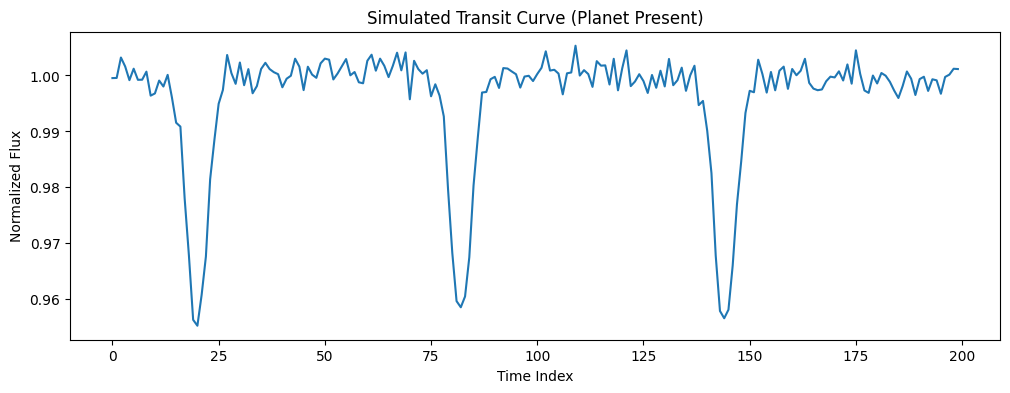

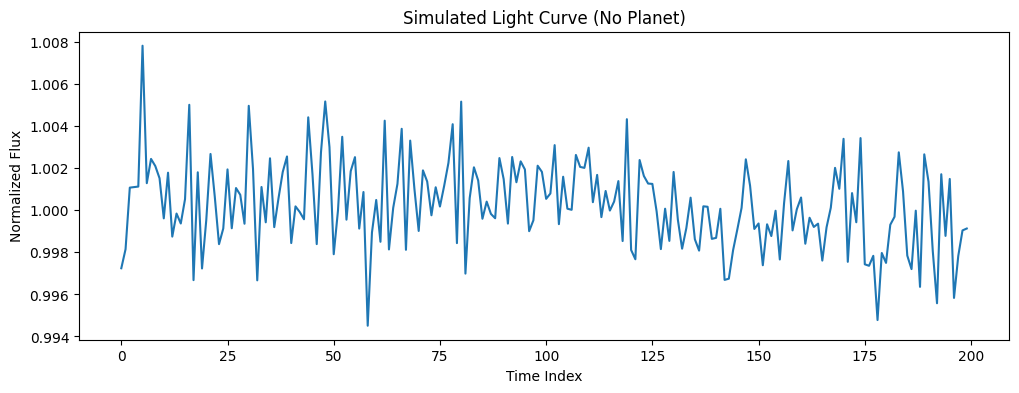

In [9]:
# simulation and example visualization
def generate_transit(has_planet=True, length=200):
    t = np.linspace(0, 10, length)
    flux = np.ones(length)

    baseline_trend = 0.001 * np.sin(0.5 * t)
    flux += baseline_trend

    if has_planet:
        period = np.random.uniform(2, 5)
        depth = np.random.uniform(0.01, 0.05)
        width = np.random.uniform(0.05, 0.15)
        inclination_factor = np.random.uniform(0.8, 1.0)

        for transit_center in np.arange(1, 10, period):
            dip = depth * np.exp(-0.5 * ((t - transit_center) / width)**2)
            flux -= inclination_factor * dip

    noise = np.random.normal(0, 0.002, length)
    flux += noise

    return flux


plt.figure(figsize=(12,4))
plt.plot(generate_transit(True))
plt.title("Simulated Transit Curve (Planet Present)")
plt.xlabel("Time Index")
plt.ylabel("Normalized Flux")
plt.show()

plt.figure(figsize=(12,4))
plt.plot(generate_transit(False))
plt.title("Simulated Light Curve (No Planet)")
plt.xlabel("Time Index")
plt.ylabel("Normalized Flux")
plt.show()

## 2. Dataset Construction

A balanced dataset of 4000 light curves is generated:
- 2000 with planetary transits
- 2000 without planetary transits

The dataset is shuffled and split into 80% training and 20% testing subsets.

In [10]:
# dataset and model training
X = []
y = []

for _ in range(2000):
    X.append(generate_transit(True))
    y.append(1)

for _ in range(2000):
    X.append(generate_transit(False))
    y.append(0)

X = np.array(X)
y = np.array(y)

indices = np.random.permutation(len(X))
X = X[indices]
y = y[indices]

split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32),
                              torch.tensor(y_train, dtype=torch.float32))
test_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.float32),
                             torch.tensor(y_test, dtype=torch.float32))

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


class TransitClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(200, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

model = TransitClassifier().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


for epoch in range(15):
    model.train()
    total_loss = 0

    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)

        outputs = model(batch_x).squeeze()
        loss = criterion(outputs, batch_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.6f}")

Epoch 1, Loss: 0.693313
Epoch 2, Loss: 0.693749
Epoch 3, Loss: 0.693581
Epoch 4, Loss: 0.693404
Epoch 5, Loss: 0.693359
Epoch 6, Loss: 0.693307
Epoch 7, Loss: 0.693209
Epoch 8, Loss: 0.693216
Epoch 9, Loss: 0.693236
Epoch 10, Loss: 0.693274
Epoch 11, Loss: 0.693425
Epoch 12, Loss: 0.693377
Epoch 13, Loss: 0.693196
Epoch 14, Loss: 0.693176
Epoch 15, Loss: 0.693192


## 3. Model Evaluation

Model performance is evaluated using:
- ROC Curve
- Area Under the Curve (AUC)

AUC is used because it measures classification performance independent of threshold choice.

Test AUC: 0.9995090681676049
Total Parameters: 36097


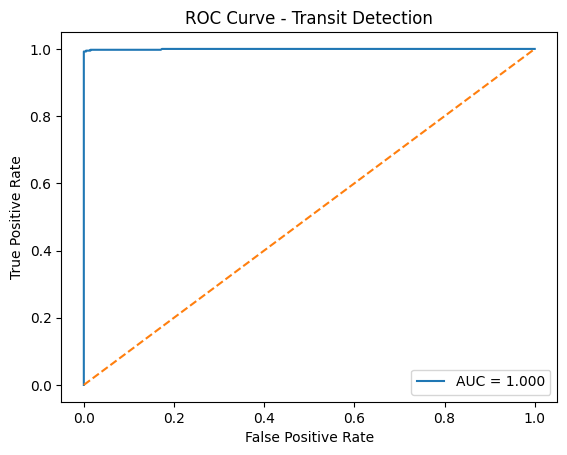


Robustness Evaluation:
Noise STD 0.002 → AUC: 0.9989184999999999
Noise STD 0.005 → AUC: 0.9883770000000001
Noise STD 0.01 → AUC: 0.9415640000000001

Model saved and reloaded successfully.


In [11]:
# evaluation and robustness
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x = batch_x.to(device)
        outputs = torch.sigmoid(model(batch_x).squeeze())

        all_preds.extend(outputs.cpu().numpy())
        all_labels.extend(batch_y.numpy())

auc = roc_auc_score(all_labels, all_preds)

print("Test AUC:", auc)
print("Total Parameters:", sum(p.numel() for p in model.parameters()))

fpr, tpr, _ = roc_curve(all_labels, all_preds)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Transit Detection")
plt.legend()
plt.show()


def evaluate_with_noise(noise_std):
    X_noisy = []
    y_noisy = []

    for _ in range(1000):
        X_noisy.append(generate_transit(True))
        y_noisy.append(1)

    for _ in range(1000):
        X_noisy.append(generate_transit(False))
        y_noisy.append(0)

    X_noisy = np.array(X_noisy)
    y_noisy = np.array(y_noisy)

    X_noisy += np.random.normal(0, noise_std, X_noisy.shape)

    X_tensor = torch.tensor(X_noisy, dtype=torch.float32).to(device)

    with torch.no_grad():
        preds = torch.sigmoid(model(X_tensor)).squeeze().cpu().numpy()

    return roc_auc_score(y_noisy, preds)


print("\nRobustness Evaluation:")
for noise in [0.002, 0.005, 0.01]:
    print(f"Noise STD {noise} → AUC:", evaluate_with_noise(noise))


torch.save(model.state_dict(), "transit_model.pt")

loaded_model = TransitClassifier().to(device)
loaded_model.load_state_dict(torch.load("transit_model.pt"))
loaded_model.eval()

print("\nModel saved and reloaded successfully.")